In [1]:
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from torch.utils.data import DataLoader, Subset
from torchvision.utils import make_grid
from transformers import ViTForImageClassification

os.chdir('../..')
sys.path.append('.')
import configs
from utils.decorator import ema_returns, mean_returns, repeats
from models import resnet18
from utils.dataset import load_cv_dataset
from utils.nn import set_seed
from utils.nn.classifier import train, test
from utils.nn.io import load_embedding

device = torch.device('cuda:0')
set_seed(0)

In [2]:
clf = IsolationForest(max_samples='auto', random_state=0, n_jobs=10)

In [3]:
bs = 128

trainset    = load_cv_dataset('cifar10', train=True, augment=False)
testset     = load_cv_dataset('cifar10', train=False, augment=False)
trainloader = DataLoader(trainset, batch_size=bs, shuffle=False, num_workers=0)
testloader  = DataLoader(testset, batch_size=bs, shuffle=False, num_workers=0)
print('CIFAR-10 training transform:\n' + '\n'.join([f'==> {str(t)}' for t in trainset.transform.transforms]))
print('CIFAR-10 test transform:\n' + '\n'.join([f'==> {str(t)}' for t in testset.transform.transforms]))

CIFAR-10 training transform:
==> ToTensor()
==> Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))
CIFAR-10 test transform:
==> ToTensor()
==> Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))


### Outlier Detection by Isolation Forest

In [4]:
def plot_score(score, dataset):
    fig, ax = plt.subplots(1, 3, figsize=(15,4), dpi=100)
    ax[0].grid(linestyle='--', alpha=0.5, zorder=0)
    ax[0].hist(score, 50, color='bisque', ec='k', label='Hist', zorder=10)
    ax[0].legend()
    ax[0].set_xlabel('Abnormal Score')
    ax[0].set_ylabel('Number of Samples')
    index = np.argsort(score)
    lower_index, upper_index = index[:20], index[-20:]

    mean = torch.Tensor([[[0.4914]], [[0.4822]], [[0.4465]]])
    std  = torch.Tensor([[[0.2023]], [[0.1994]], [[0.201]]])
    image_batch = torch.stack([dataset[i][0] * std + mean for i in lower_index]) 
    ax[1].imshow(make_grid(image_batch, nrow=5, pad_value=0.9).clip(0,1).permute((1,2,0)))
    ax[1].set_xlabel('Outlier Samples')
    image_batch = torch.stack([dataset[i][0] * std + mean for i in upper_index])
    ax[2].imshow(make_grid(image_batch, nrow=5, pad_value=0.9).clip(0,1).permute((1,2,0)))
    ax[2].set_xlabel('Normal Samples')
    fig.show()

#### Raw Image Input (+PCA)


time cost for processing images: 9.51s.
time cost for fitting isolation tree: 82.54s.


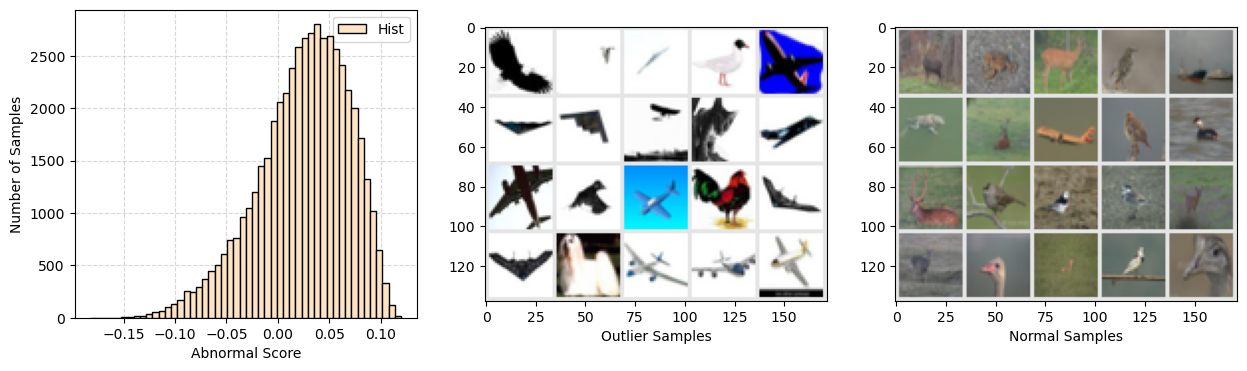

In [5]:
# raw image.
t0 = time.time()
raw_iamge = np.vstack([data[0].reshape(data[0].size(0), -1).numpy() for data in trainloader])
raw_input_process_time = time.time() - t0
print(f'time cost for processing images: {raw_input_process_time:.2f}s.')

t0 = time.time()
raw_input_outlier = clf.fit_predict(raw_iamge)
raw_input_score   = clf.decision_function(raw_iamge)
raw_input_fit_time = time.time() - t0
print(f'time cost for fitting isolation tree: {raw_input_fit_time:.2f}s.')
plot_score(raw_input_score, trainset)

time cost for pca fitting: 1.62s.
time cost for fitting isolation tree: 3.01s.


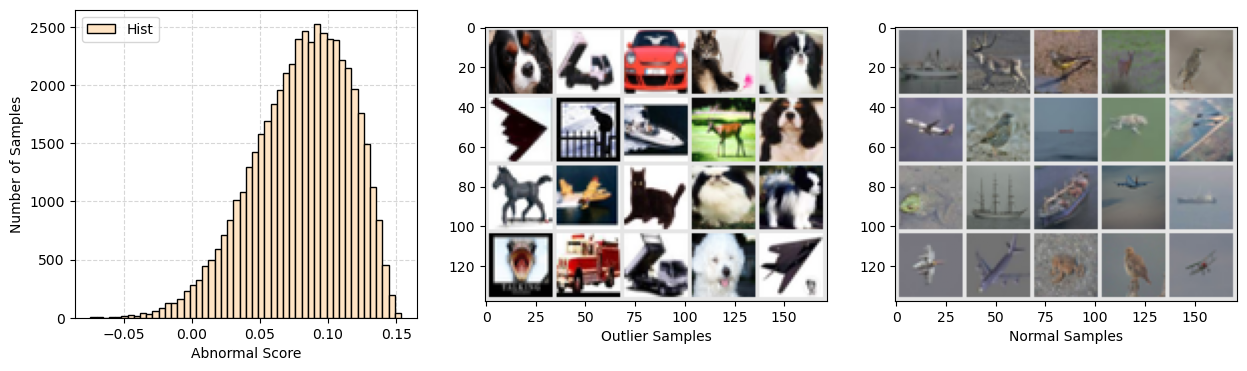

In [6]:
# +PCA.
pca = PCA(n_components=50)

t0 = time.time()
pca_raw_iamge = pca.fit_transform(raw_iamge)
raw_input_pca_time = time.time() - t0
print(f'time cost for pca fitting: {raw_input_pca_time:.2f}s.')

t0 = time.time()
raw_input_pca_outlier = clf.fit_predict(pca_raw_iamge)
raw_input_pca_score   = clf.decision_function(pca_raw_iamge)
raw_input_pca_fit_time = time.time() - t0
print(f'time cost for fitting isolation tree: {raw_input_pca_fit_time:.2f}s.')
plot_score(raw_input_pca_score, trainset)

### Supervised Embedding (+PCA)

In [7]:
# load model.
model = resnet18(**configs.resnet18_cifar10_params)
state = load_embedding('resnet18', 'cifar10', 'sl', '230429-1218')
model.load_state_dict(state, strict=False)
model.fc = nn.Identity()
model = model.to(device)

time cost for processing images: 16.01s.
time cost for fitting isolation tree: 18.57s.


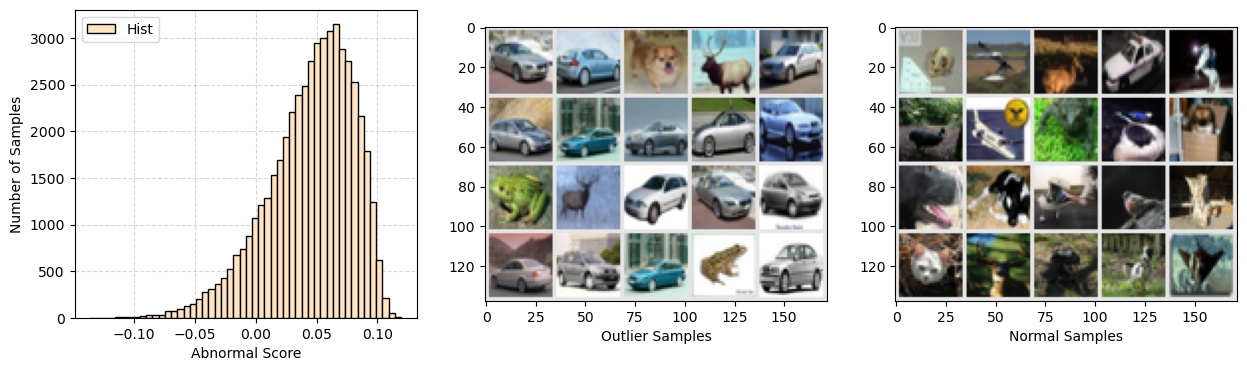

In [8]:
# supervised embedding.
t0 = time.time()
with torch.no_grad():
    sl_embed_x = torch.cat([model(x.to(device)).cpu() for x, _ in trainloader], dim=0).numpy()
sl_embed_process_time = time.time() - t0
print(f'time cost for processing images: {sl_embed_process_time:.2f}s.')

t0 = time.time()
sl_embed_outlier = clf.fit_predict(sl_embed_x)
sl_embed_score   = clf.decision_function(sl_embed_x)
sl_embed_fit_time = time.time() - t0
print(f'time cost for fitting isolation tree: {sl_embed_fit_time:.2f}s.')
plot_score(sl_embed_score, trainset)

time cost for pca fitting: 0.49s.
time cost for fitting isolation tree: 3.08s.


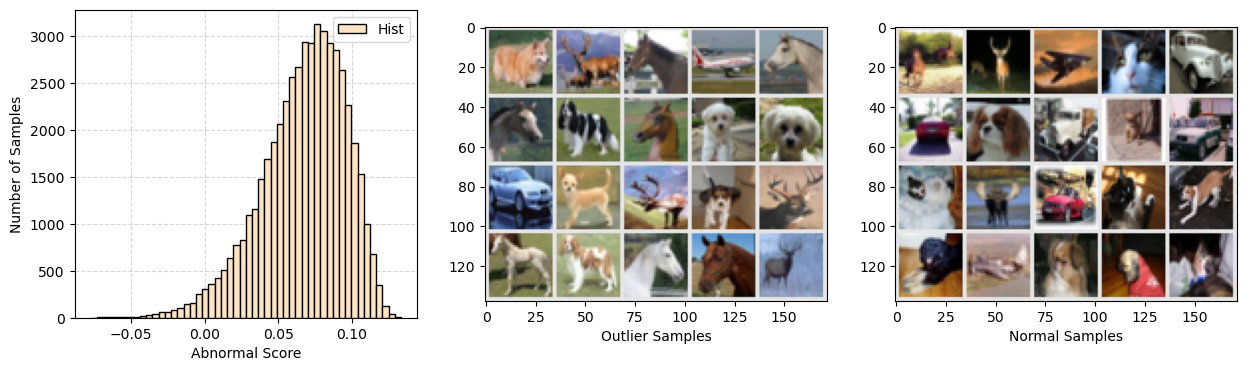

In [9]:
# +PCA.
pca = PCA(n_components=50)

t0 = time.time()
sl_embed_pca_x = pca.fit_transform(sl_embed_x)
sl_embed_pca_time = time.time() - t0
print(f'time cost for pca fitting: {sl_embed_pca_time:.2f}s.')

t0 = time.time()
sl_embed_pca_outlier = clf.fit_predict(sl_embed_pca_x)
sl_embed_pca_score   = clf.decision_function(sl_embed_pca_x)
sl_embed_pca_fit_time = time.time() - t0
print(f'time cost for fitting isolation tree: {sl_embed_pca_fit_time:.2f}s.')
plot_score(sl_embed_pca_score, trainset)

#### Pre-trained Embedding (+PCA)

In [10]:
# load training set with size of 224 * 224.
bs = 128
trainset    = load_cv_dataset('cifar10', train=True, augment=False, resize=224)
trainloader = DataLoader(trainset, batch_size=bs, shuffle=True, num_workers=0)

# load model.
vit_name = 'google/vit-base-patch16-224-in21k'
model = ViTForImageClassification.from_pretrained(vit_name, num_labels=len(trainset.classes), return_dict=False)
model.classifier = nn.Identity()
model = model.to(device)

Some weights of the model checkpoint at google/vit-base-patch16-224-in21k were not used when initializing ViTForImageClassification: ['pooler.dense.weight', 'pooler.dense.bias']
- This IS expected if you are initializing ViTForImageClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ViTForImageClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


time cost for processing images: 246.00s.
time cost for fitting isolation tree: 23.41s.


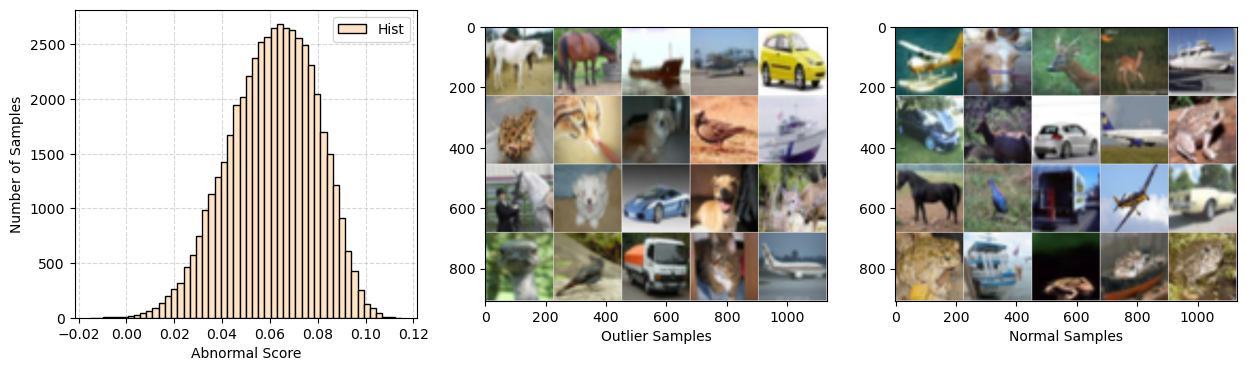

In [11]:
# pretrained embedding.
t0 = time.time()
with torch.no_grad():
    vit_embed_x = torch.cat([model(x.to(device))[0].detach().cpu() for x, _ in trainloader], dim=0).numpy()
vit_embed_process_time = time.time() - t0
print(f'time cost for processing images: {vit_embed_process_time:.2f}s.')

t0 = time.time()
vit_embed_outlier = clf.fit_predict(vit_embed_x)
vit_embed_score   = clf.decision_function(vit_embed_x)
vit_embed_fit_time = time.time() - t0
print(f'time cost for fitting isolation tree: {vit_embed_fit_time:.2f}s.')
plot_score(vit_embed_score, trainset)

time cost for pca fitting: 0.62s.
time cost for fitting pca and isolation tree: 3.17s.


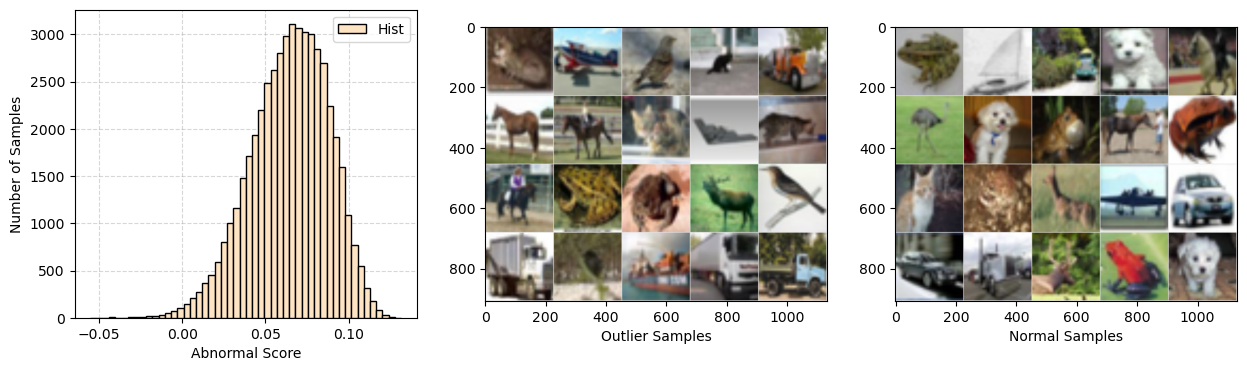

In [12]:
# +PCA.
pca = PCA(n_components=50)

t0 = time.time()
vit_embed_pca_x = pca.fit_transform(vit_embed_x)
vit_embed_pca_time = time.time() - t0
print(f'time cost for pca fitting: {vit_embed_pca_time:.2f}s.')

t0 = time.time()
vit_embed_pca_outlier = clf.fit_predict(vit_embed_pca_x)
vit_embed_pca_score   = clf.decision_function(vit_embed_pca_x)
vit_embed_pca_fit_time = time.time() - t0
print(f'time cost for fitting pca and isolation tree: {vit_embed_pca_fit_time:.2f}s.')
plot_score(vit_embed_pca_score, trainset)

#### Statistics and Correlation of Outlier Detection Results

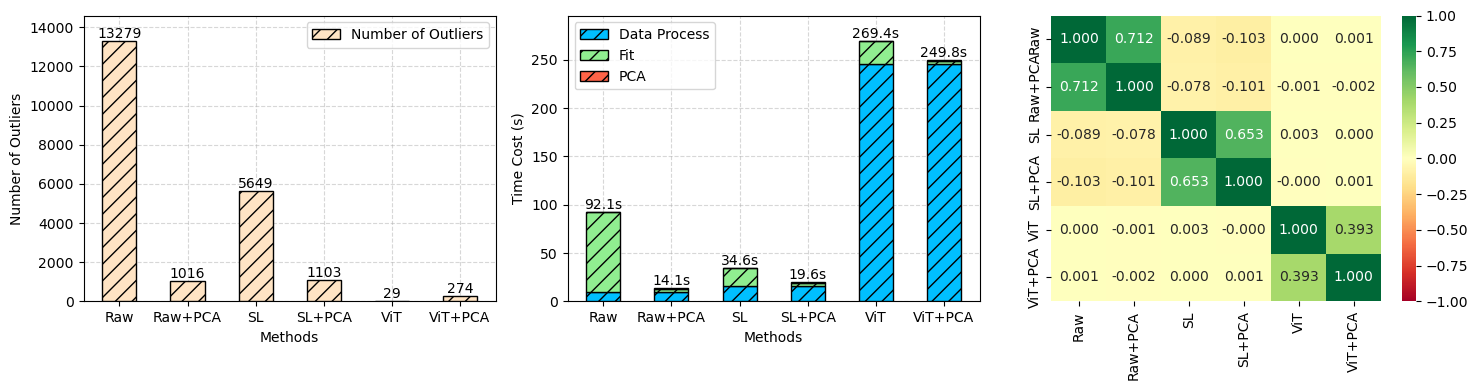

In [13]:
n_outlier = [sum(raw_input_outlier == -1), sum(raw_input_pca_outlier == -1), 
             sum(sl_embed_outlier == -1), sum(sl_embed_pca_outlier == -1), 
             sum(vit_embed_outlier == -1), sum(vit_embed_pca_outlier == -1)]

process_time_cost = np.array([raw_input_process_time] * 2 + [sl_embed_process_time] * 2 + [vit_embed_process_time] * 2)
fit_time_cost     = np.array([raw_input_fit_time, raw_input_pca_fit_time, sl_embed_fit_time, sl_embed_pca_fit_time, vit_embed_fit_time, vit_embed_pca_fit_time])
pca_time_cost     = np.array([0., raw_input_pca_time, 0., sl_embed_pca_time, 0., vit_embed_pca_time])
total_time_cost   = process_time_cost + fit_time_cost + pca_time_cost

df = pd.DataFrame(
    {'Raw': raw_input_score,
     'Raw+PCA': raw_input_pca_score,
     'SL': sl_embed_score,
     'SL+PCA': sl_embed_pca_score,
     'ViT': vit_embed_score,
     'ViT+PCA': vit_embed_pca_score}
    )

fig, ax = plt.subplots(1, 3, figsize=(15,4), dpi=100)
# number of outliers.
ax[0].grid(linestyle='--', alpha=0.5, zorder=0)
ax[0].bar(np.arange(6), n_outlier, width=0.5, color='bisque', ec='k', hatch='//', label='Number of Outliers', zorder=10)
for i, v in enumerate(n_outlier): ax[0].text(i, v, v, ha='center', va='bottom')
ax[0].set_xlabel('Methods')
ax[0].set_ylabel('Number of Outliers')
ax[0].set_xticks(np.arange(6), df.columns)
ax[0].set_ylim((0, int(max(n_outlier) * 1.1)))
ax[0].legend()

# time costs.
ax[1].grid(linestyle='--', alpha=0.5, zorder=0)
ax[1].bar(np.arange(6), process_time_cost, width=0.5, color='deepskyblue', ec='k', hatch='//', label='Data Process', zorder=10)
ax[1].bar(np.arange(6), fit_time_cost, width=0.5, bottom=process_time_cost, color='lightgreen', ec='k', hatch='//', label='Fit', zorder=10)
ax[1].bar(np.arange(6), pca_time_cost, width=0.5, bottom=process_time_cost + fit_time_cost, color='tomato', ec='k', hatch='//', label='PCA', zorder=10)
for i, v in enumerate(total_time_cost): ax[1].text(i, v, f'{v:.1f}s', ha='center', va='bottom')
ax[1].set_xlabel('Methods')
ax[1].set_ylabel('Time Cost (s)')
ax[1].set_xticks(np.arange(6), df.columns)
ax[1].set_ylim((0, int(max(total_time_cost) * 1.1)))
ax[1].legend()

# correlation.
sns.heatmap(df.corr(), vmin=-1, vmax=1, cmap='RdYlGn', annot=True, fmt='.3f', ax=ax[2])
fig.tight_layout()
fig.show()

### Downstream Task Performance

In [14]:
@mean_returns
@repeats(n=3)
@ema_returns(gamma=0.95)
def train_test_loop(trainloader, testloader, epoch, lr):
    train_losses, train_accs = list(), list()
    test_losses, test_accs   = list(), list()
    model = resnet18(**configs.resnet18_cifar10_params).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epoch):
        train_loss, train_acc, _ = train(model, trainloader, optimizer)
        test_loss, test_acc   = test(model, testloader)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
    return train_losses, test_losses, train_accs, test_accs

In [15]:
bs = 512

trainset       = load_cv_dataset('cifar10', train=True, augment=False)
raw_data_index = set(range(len(trainset)))

clean_raw_data           = Subset(trainset, list(raw_data_index - set(raw_input_outlier)))
clean_raw_pca_data       = Subset(trainset,  list(raw_data_index - set(raw_input_pca_outlier)))
clean_sl_embed_data      = Subset(trainset,  list(raw_data_index - set(sl_embed_outlier)))
clean_sl_embed_pca_data  = Subset(trainset,  list(raw_data_index - set(sl_embed_pca_outlier)))
clean_vit_embed_data     = Subset(trainset,  list(raw_data_index - set(vit_embed_outlier)))
clean_vit_embed_pca_data = Subset(trainset,  list(raw_data_index - set(vit_embed_pca_outlier)))

trainloader                    = DataLoader(trainset, bs, shuffle=True)
clean_raw_dataloader           = DataLoader(clean_raw_data, bs, shuffle=True)
clean_raw_pca_dataloader       = DataLoader(clean_raw_pca_data, bs, shuffle=True)
clean_sl_embed_dataloader      = DataLoader(clean_sl_embed_data, bs, shuffle=True)
clean_sl_embed_pca_dataloader  = DataLoader(clean_sl_embed_pca_data, bs, shuffle=True)
clean_vit_embed_dataloader     = DataLoader(clean_vit_embed_data, bs, shuffle=True)
clean_vit_embed_pca_dataloader = DataLoader(clean_vit_embed_pca_data, bs, shuffle=True)

In [16]:
epoch = 10
lr    = 1e-3

raw_ret                 = train_test_loop(trainloader, testloader, epoch=epoch, lr=lr)
clean_raw_ret           = train_test_loop(clean_raw_dataloader, testloader, epoch=epoch, lr=lr)
clean_raw_pca_ret       = train_test_loop(clean_raw_pca_dataloader, testloader, epoch=epoch, lr=lr)
clean_sl_embed_ret      = train_test_loop(clean_sl_embed_dataloader, testloader, epoch=epoch, lr=lr)
clean_sl_embed_pca_ret  = train_test_loop(clean_sl_embed_pca_dataloader, testloader, epoch=epoch, lr=lr)
clean_vit_embed_ret     = train_test_loop(clean_vit_embed_dataloader, testloader, epoch=epoch, lr=lr)
clean_vit_embed_pca_ret = train_test_loop(clean_vit_embed_pca_dataloader, testloader, epoch=epoch, lr=lr)

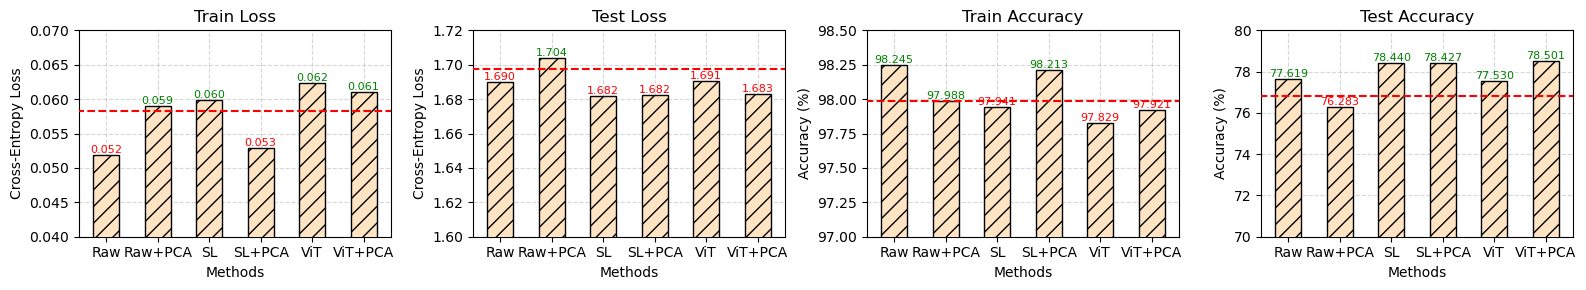

In [17]:
rets = [clean_raw_ret, clean_raw_pca_ret, clean_sl_embed_ret, clean_sl_embed_pca_ret, clean_vit_embed_ret, clean_vit_embed_pca_ret]
x_ticklabels = ['Raw', 'Raw+PCA', 'SL', 'SL+PCA', 'ViT', 'ViT+PCA']
y_labels = ['Cross-Entropy Loss', 'Cross-Entropy Loss', 'Accuracy (%)', 'Accuracy (%)']
titles   = ['Train Loss', 'Test Loss', 'Train Accuracy', 'Test Accuracy']
ylims    = [(0.04, 0.07), (1.6, 1.72), (97, 98.5), (70, 80)]

fig, axs = plt.subplots(1, 4, figsize=(16, 3), dpi=100)
for i, ax in enumerate(axs):
    y = [ret[i] for ret in rets]
    ax.grid(linestyle='--', alpha=0.5, zorder=0)
    ax.axhline(raw_ret[i], c='r', linestyle='--', xmin=-0.5, xmax=6.5, zorder=20)
    ax.bar(np.arange(6), y, width=0.5, color='bisque', ec='k', hatch='//', label='Number of Outliers', zorder=10)
    for j, v in enumerate(y): ax.text(j, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8, c='r' if v < raw_ret[i] else 'g')
    ax.set_xlabel('Methods')
    ax.set_ylabel(y_labels[i])
    ax.set_xticks(np.arange(6), x_ticklabels)
    ax.set_ylim(ylims[i])
    ax.set_title(titles[i])
fig.tight_layout()
fig.show()